In [2]:
# sklearn 라이브러리에 포함된 datasets 모듈에서 아이리스 데이터를 로드.
from sklearn import datasets
iris = datasets.load_iris()
samples = iris.data
print(samples)
print(samples.shape)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

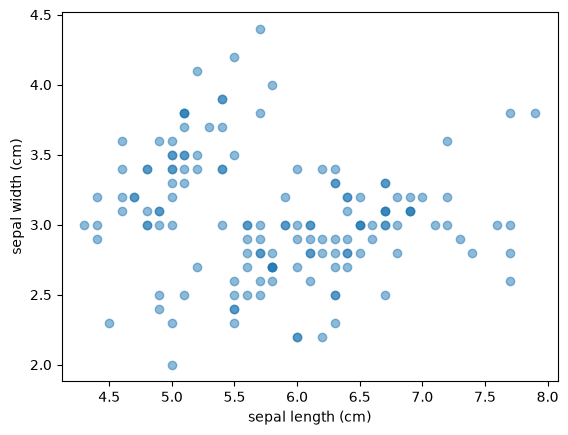

In [3]:
# sepal length와 width 두 가지 feature만을 사용하도록 하겠음
# 데이터로부터 두 feature만을 뽑아내어 산점도를 그려 봄(x축-length, y축-width)
from matplotlib import pyplot as plt
x = samples[:, 0]
y = samples[:, 1]
plt.scatter(x, y, alpha=0.5)     # alpha – 색상의 투명도 지정(0-완전투명, 1-불투명)
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')
plt.show()

# Iris Dataset은 원래 label이 제공되지만, label이 없다고 가정하고 K-Mean 알고리즘으로 위 # 데이터를 그룹화 함. K-Means 클러스터링 알고리즘 사용

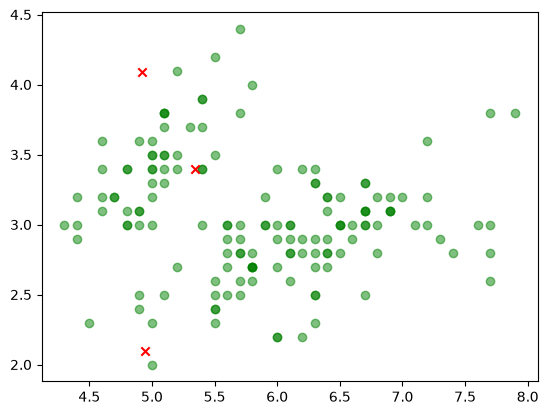

In [4]:
# STEP 1: Place K Random Centroids : 제일 먼저 K 개의 centroids(중심값)를 임의로 지정
# 3가지 종이 존재하므로 K 는 3 으로 설정 <- 일단 답(3)을 안다고 가정하고 진행, 어떻게 k를 정하는지는 추후에 설명해 주실 것임
import numpy as np
k = 3
# 랜덤으로 x, y 좌표 3개를 생성합니다
# np.random.uniform은 주어진 최소, 최대값 사이에서 k 개 만큼 실수 난수를 생성합니다.
centroids_x = np.random.uniform(min(x), max(x), k)
centroids_y = np.random.uniform(min(y), max(y), k)
centroids = list(zip(centroids_x, centroids_y))

# centroids 는 임의로 생성한 (x, y) 좌표 3개를 갖게 됨. 
plt.scatter(x, y, alpha=0.5, color='green')    # 데이터들은 파란색으로 표시되고 = default
plt.scatter(centroids_x, centroids_y, marker='x', color='red')    # centroids는 주황색으로 표시 = default
plt.show()

In [5]:
print(centroids_x)
print(centroids_y)
print(centroids)

[4.92274882 5.3438716  4.94599216]
[4.08868166 3.39936576 2.09920446]
[(4.92274882258879, 4.088681655253433), (5.343871602295495, 3.399365760293445), (4.945992155430947, 2.0992044594473183)]


In [6]:
# STEP 2: Assign Datas to Nearest Centroid
# centroids에 가까운 데이터들을 할당. ‘가깝다’ 라는 것을 정량적으로 계산하기 위해 
# 각 데이터를 벡터로 간주하여 유클리드 거리를 계산.
# 두 데이터 포인트 사이의 거리를 계산하는 distance() 함수를 작성.
def distance(a, b):
    return sum([(el_a - el_b)**2 for el_a, el_b in list(zip(a, b))]) ** 0.5
    
# 각 데이터들 별로 3개의 centroids와의 거리를 측정.labels 란 배열을 생성하고, 가장 
# 가까운 centroids의 index를 저장.
# 각 데이터 포인트를 그룹화 할 labels을 생성합니다 (0, 1, 또는 2)
labels = np.zeros(len(samples))    # samples는 iris data 
sepal_length_width = np.array(list(zip(x, y)))

# 각 데이터를 순회하면서 centroids와의 거리를 측정합니다
for i in range(len(samples)):
    distances = np.zeros(k)    # 초기 거리는 모두 0으로 초기화, 3개 요소 1차원 배열(k=3)
    print(f"---sepal_length_width[{i}] = {sepal_length_width[i]}")
    for j in range(k):     # 3번 반복(각각의 x,y에 대해 세 중심과의 거리를 구해 distance[0][1][2]에 집어 넣음)
        distances[j] = distance(sepal_length_width[i], centroids[j])
        print(f"distances[{j}] = {distances[j]}")
    cluster = np.argmin(distances) # np.argmin은 가장 작은 값의 index를 반환(세 중심중 어디에 가까운지)
    print(cluster)
    labels[i] = cluster #label에는 각각 x,y에 대해 세 중심중 어디에 속하는지에 대한 정보가 있음
    print(labels)

---sepal_length_width[0] = [5.1 3.5]
distances[0] = 0.6147878261039185
distances[1] = 0.2638192726233032
distances[2] = 1.4092361628276098
1
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
---sepal_length_width[1] = [4.9 3. ]
distances[0] = 1.0889193061997438
distances[1] = 0.5970887788420842
distances[2] = 0.9019688931669331
1
[1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0

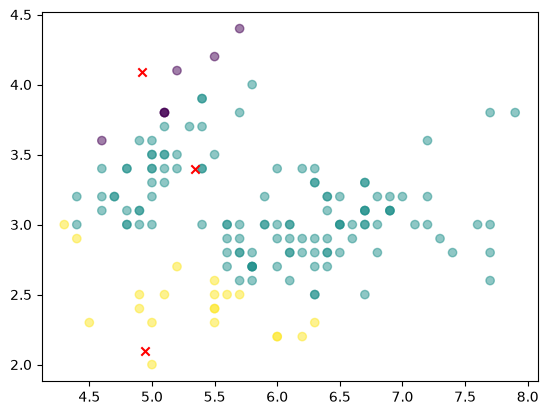

In [7]:
# 생성된 labels에는 0, 1 또는 2 가 저장되어 각 데이터(iris data)가 어느 centroid그룹에
# 속해 있는지를 나타냄. 시각화를 통해 확인.
plt.scatter(x, y, c=labels, alpha=0.5)
plt.scatter(centroids_x, centroids_y, c='red', marker='x')    # centroid는 빨간색으로… 
plt.show()

# 데이터들이 가까운 centroid에 잘 할당되어 있지만, 처음 centroid를 선택할 때 랜덤으로 
# 선택했으므로 최적화가 필요.

In [8]:
# STEP 3: Update Centroids - centroids를 새롭게 지정함으로써 데이터를 더 잘 그룹화 할 수 # 있도록 만들어야 함. 기존에 지정한 centroids를 복사해두어 centroids_old 에 저장
from copy import deepcopy
centroids_old = deepcopy(centroids)

# 각 그룹별로 데이터의 평균을 계산. 즉, 각 데이터들의 평균 x좌표와 평균 y좌표를 계산하여 # 하나의 좌표를 계산. 이렇게 계산된 좌표는 새로운 centroid로 지정.
for i in range(k):
  # 각 그룹에 속한 데이터들만 골라 points에 저장.labels에 섞인 값을 sepal_length_width
  # 에 구분하여 저장 points는 각각 그룹의 x,y 좌표를 가진 list
  points = [ sepal_length_width[j] for j in range(len(sepal_length_width)) if labels[j] == i ]
  # points의 각 feature, 즉 각 좌표의 평균 지점을 centroid로 지정
  centroids[i] = np.mean(points, axis=0)

#data및 type 확인
print(centroids)
print(type(centroids))
print(centroids_old)
print(type(centroids_old))

[array([5.18571429, 3.95714286]), array([5.96422764, 3.10731707]), array([5.33 , 2.435])]
<class 'list'>
[(4.92274882258879, 4.088681655253433), (5.343871602295495, 3.399365760293445), (4.945992155430947, 2.0992044594473183)]
<class 'list'>


<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


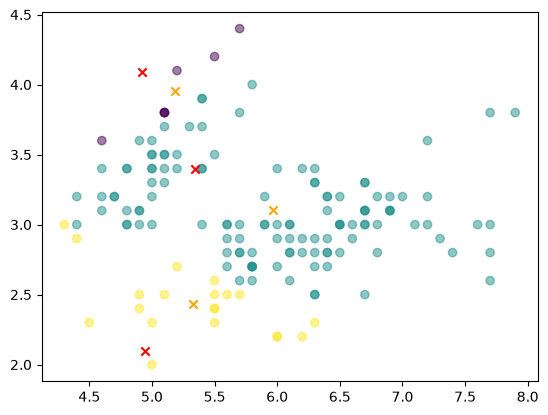

In [9]:
centroids= np.array(centroids)
centroids_old= np.array(centroids_old)
print(type(centroids))
print(type(centroids_old))
# 기존 centroids_old 와 centroids 위치 비교
plt.scatter(x, y, c=labels, alpha=0.5)
plt.scatter(centroids[:, 0], centroids[:, 1], c='orange', marker='x')
plt.scatter(centroids_old[:, 0], centroids_old[:, 1], c='red', marker='x')
plt.show()
# Centroids가 전체적으로 중앙으로 이동, 데이터의 중심 지점에 위치한 것을 확인 할 수 있음, 거리(X) 무게(o) 중심으로 이동함

In [10]:
# STEP 4: Repeat Step 2 ~ 3 Until Convergence(집중점, 집합점)
# 필요한 모든 building blocks를 구현. 2 ~ 3단계를 반복하여 최적의 centroids를 찾는 것
# 이 목표. 그런데 언제까지 찾아야 할까?
# error 라는 배열 생성. error의 각 index는 centroids_old 와 새롭게 지정된 centroids 의 
# 거리를 저장. 이 거리가 모두 0 이 되면 최적해에 수렴(convergence)한 것으로 판단하여 
# 반복을 종료.
centroids_old = np.zeros(centroids.shape)    # 제일 처음 centroids_old는 0으로 초기화
labels = np.zeros(len(samples))
error = np.zeros(k)    # error 도 초기화

for i in range(k):
  error[i] = distance(centroids_old[i], centroids[i])

In [11]:
while error.all() != 0:    #열의 데이터 중 조건과 맞는 데이터가 있으면 True 전혀 없으면 False
  # STEP 2: 가까운 centroids에 데이터를 할당합니다
  for i in range(len(samples)):
    distances = np.zeros(k)    # 초기 거리는 모두 0으로 초기화 해줍니다
    for j in range(k):
      distances[j] = distance(sepal_length_width[i], centroids[j])
    cluster = np.argmin(distances)    # np.argmin은 가장 작은 값의 index를 반환
    labels[i] = cluster
  # Step 3: centroids를 업데이트
  centroids_old = deepcopy(centroids)
  for i in range(k):
    # 각 그룹에 속한 데이터들만 골라 points에 저장합니다
    points = [ sepal_length_width[j] for j in range(len(sepal_length_width)) if labels[j] == i ]
    # points의 각 feature, 즉 각 좌표의 평균 지점을 centroid로 지정합니다
    centroids[i] = np.mean(points, axis=0)
  # 새롭게 centroids를 업데이트 했으니 error를 다시 계산합니다
  for i in range(k):
    error[i] = distance(centroids_old[i], centroids[i])

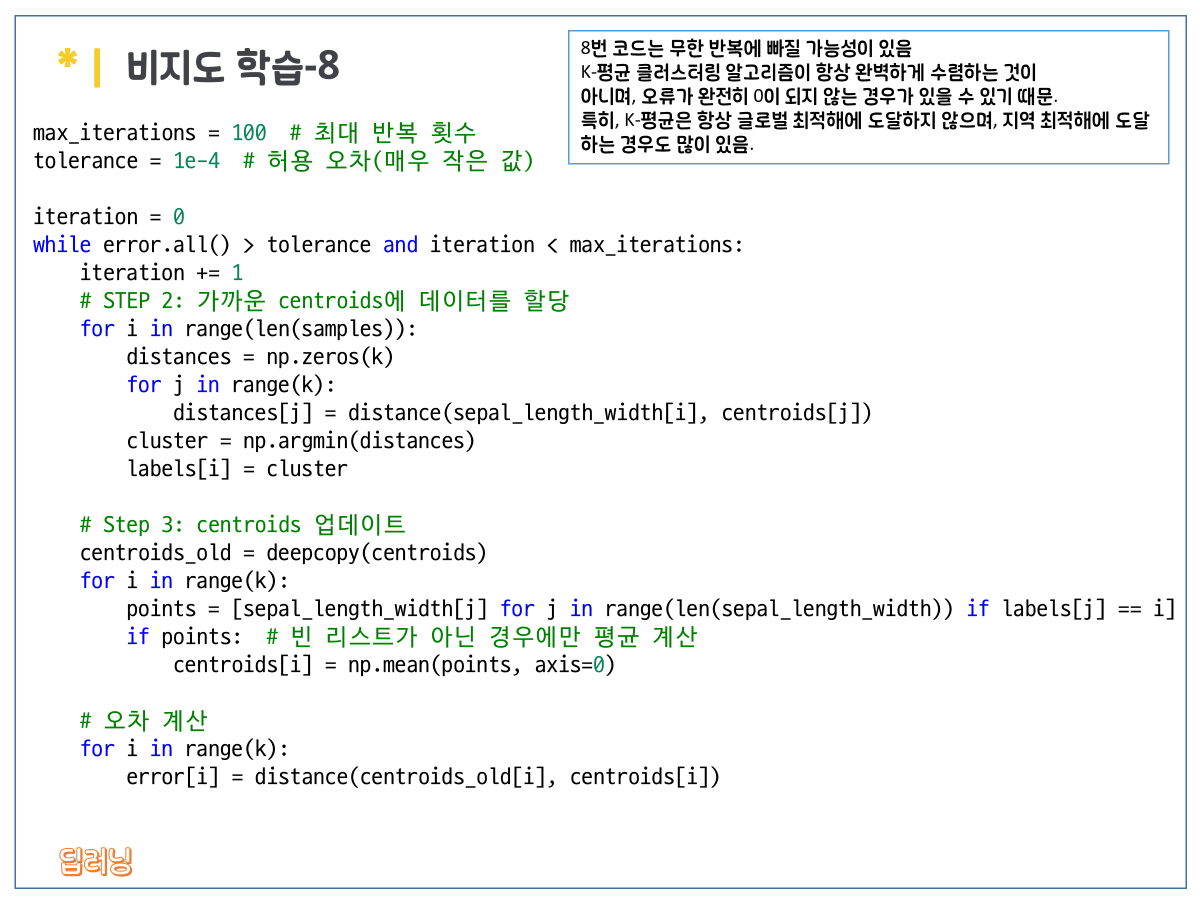

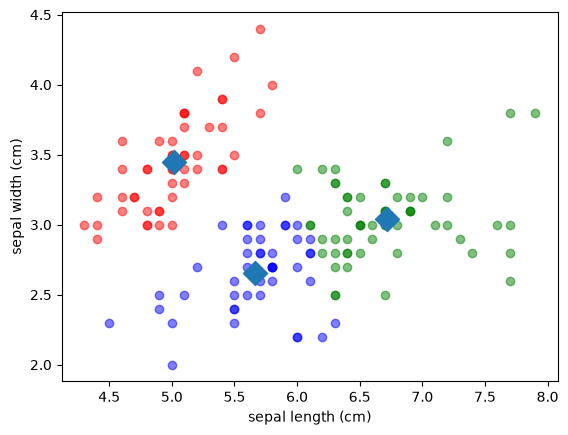

In [12]:
# 최적의 centroids를 찾았으니 이를 시각화하여 확인
# 직관적으로 알아보기위해 색을 r, g, b 로 설정. centroids는 다이아몬드 형태로 마킹.
colors = ['r', 'g', 'b']
for i in range(k):
    points = np.array([sepal_length_width[j] for j in range(len(sepal_length_width)) if labels[j] == i])
    plt.scatter(points[:, 0], points[:, 1], c=colors[i], alpha=0.5)    #alpha : 색상 투명도

plt.scatter(centroids[:, 0], centroids[:, 1], marker='D', s=150)
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')
plt.show()

# 2026.10.6(화) 19h30~ scikit-learn 라이브러리 활용

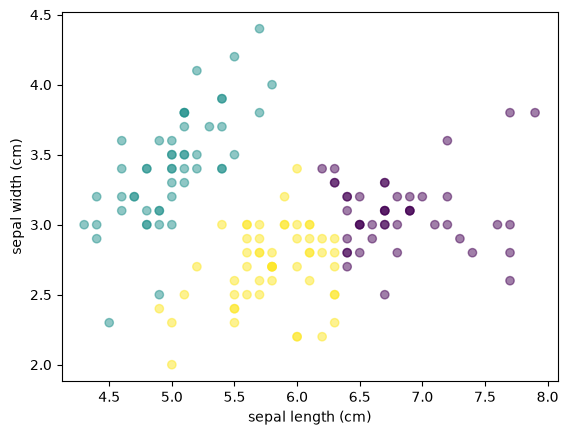

In [13]:
import matplotlib.pyplot as plt
from sklearn import datasets
#sklearn 라이브러리의 cluster 모듈에는 K-Means를 구현할 수 있는 KMeans 를 제공
from sklearn.cluster import KMeans 

iris = datasets.load_iris()
samples = iris.data[:,0:2]
# 3개의 그룹으로 나누는 K-Means 모델을 생성합니다
model = KMeans(n_clusters = 3)    #k를 지정해 주어야 함
# .fit() 메서드를 통해 K-Mean 클러스터링을 수행.
model.fit(samples)
#K-Means를 수행한 다음, .predict() 메서드를 통해 unlabeled 데이터를 그룹에 할당.
labels = model.predict(samples)
# 클러스터링 결과를 시각화합니다
x = samples[:, 0]
y = samples[:, 1]
plt.scatter(x, y, c=labels, alpha=0.5)
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')
plt.show()

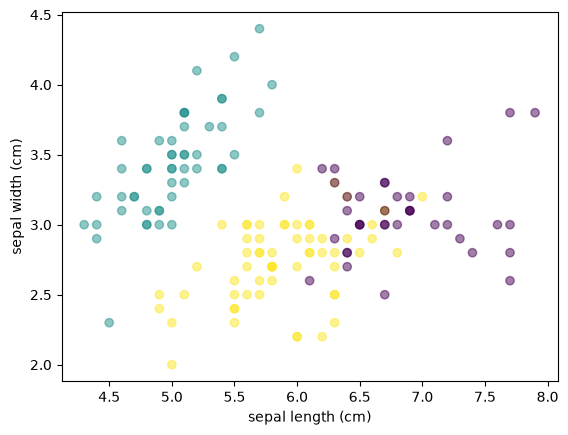

In [15]:
import matplotlib.pyplot as plt
from sklearn import datasets
#sklearn 라이브러리의 cluster 모듈에는 K-Means를 구현할 수 있는 KMeans 를 제공
from sklearn.cluster import KMeans 

iris = datasets.load_iris()
samples = iris.data
# 3개의 그룹으로 나누는 K-Means 모델을 생성합니다
model = KMeans(n_clusters = 3)    #k를 지정해 주어야 함
# .fit() 메서드를 통해 K-Mean 클러스터링을 수행.
model.fit(samples)
#K-Means를 수행한 다음, .predict() 메서드를 통해 unlabeled 데이터를 그룹에 할당.
labels = model.predict(samples)
# 클러스터링 결과를 시각화합니다
x = samples[:, 0]
y = samples[:, 1]
plt.scatter(x, y, c=labels, alpha=0.5)
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')
plt.show()

In [16]:
import numpy as np
# Evaluation : Iris 데이터를 3가지 서로 다른 그룹으로 클러스터링 하는 것을 Python과 sklearn 을 
# 활용하여 구현. 실제로 얼마나 많은 데이터를 올바르게 분류한 것일지 확인.
# Iris 데이터셋은 label이 포함되어 있으며, target 이라는 내장 속성을 통해 접근 가능
target = iris.target
#문자열 배열을 생성시킴
species = np.chararray(target.shape, itemsize=150)
print(species)
for i in range(len(samples)):
  if target[i] == 0:
    species[i] = 'setosa'
  elif target[i] == 1:
    species[i] = 'versicolor'
  elif target[i] == 2:
    species[i] = 'virginica'
# 다음으로 cross-tabulation 을 통해 결과를 분석
# Pandas 라이브러리를 활용하면 이를 쉽게 구현 할 수 있음.
import pandas as pd
# labels : 비지도 학습 데이터
# species : 원 데이터
df = pd.DataFrame({'labels': labels, 'species': species})
ct = pd.crosstab(df['labels'], df['species'])    #빈도표를 만들어주는 pandas 함수
print(ct)

[b'\x00\x00\x00\x00\x00\x00\x00\x00\xe6\x1f\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xe6\x94)E\x93\x7f\x00\x00\x18\x00\x00\x00\x00\x00\x00\x00\xe0\xe0>\x03\x01\x00\x00\x00\x01\x00\x00\x00\x93\x7f\x00\x00\xe8\x94)E\x93\x7f\x00\x00\t\x00\x00\x00\x04\x00\x00\x00\t\x00\x00\x00\x05\x00\x00\x00\x18\x00\x00\x00\x93\x7f\x00\x00\xe0\xe0>\x03\x01\x00\x00\x00\x02\x00\x00\x00\x00\x00\x00\x000\x94)E\x93\x7f\x00\x00\t\x00\x00\x00\x04\x00\x00\x00\t\x00\x00\x00\x05\x00\x00\x00\x93\x04\x00\x00\x00\x00\x00\x00P\x94)E\x93\x7f\x00\x00!\x00\x00\x00\x93\x7f'
 b'\x00\x00\xb0\x91)E\x93\x7f\x00\x00\x92\x04\x00\x00\x00\x00\x00\x00P\x94)E\x93\x7f\x00\x00!\x00\x00\x00\x93\x7f\x00\x00\x80\x94)E\x93\x7f\x00\x00b\x04\x00\x00\x00\x00\x00\x00\xc0\x9b)E\x93\x7f\x00\x00)\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00c\x04\x00\x00\x01\x00\x00\x00\xc0\x9b)E\x93\x7f\x00\x00)\x00\x00\x00\x01\x00\x00\x00\xc0\x94)E\x93\x7f\x00\x00d\x04\x00\x00\x93\x7f\x00\x00\xc0\x9b)E\x93\x7f\x00\x00)\x00\x00\x00\

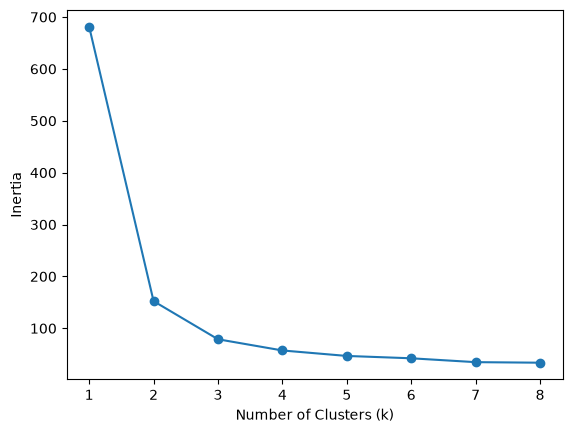

In [17]:
num_clusters = list(range(1, 9))    # K는 1 ~ 8사이의 정수
inertias = []
# 각 K별로 모델을 생성하여 inertia를 측정합니다
for i in num_clusters:
    model = KMeans(n_clusters=i)
    model.fit(samples)
    inertias.append(model.inertia_)
# K에 따른 inertia의 변화를 시각화합니다
plt.plot(num_clusters, inertias, '-o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()